# Experiment 2 - 정규화 방법 비교
실험 목적: 전체 feature(stress_level 제외) 고정 후 StandardScaler vs MinMaxScaler 성능 비교

## 1. 라이브러리 임포트

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## 2. 데이터 로드 및 결측치 처리

In [2]:
data = pd.read_csv('/content/sample_data/developer_burnout_dataset_7000.csv')
print('데이터 크기:', data.shape)
data.head()

데이터 크기: (7000, 12)


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [3]:
data.fillna(data.mean(numeric_only=True), inplace=True)

data['burnout_level'].fillna(data['burnout_level'].mode()[0], inplace=True)

print('결측치 처리 후:')
print(data.isnull().sum())

결측치 처리 후:
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day    0
screen_time         0
exercise_hours      0
stress_level        0
burnout_level       0
dtype: int64


/tmp/ipykernel_1538/4063124320.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['burnout_level'].fillna(data['burnout_level'].mode()[0], inplace=True)


## 3. 타겟 라벨 인코딩

In [4]:
data['burnout_level'] = data['burnout_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
print(data['burnout_level'].value_counts())

burnout_level
1    3625
2    1782
0    1593
Name: count, dtype: int64


## 4. Feature / Target 정의

- experiment1 결과: 전체 feature(stress_level 제외)가 더 좋은 모델 → 고정
- 이번 실험 변수: 정규화 방법 (StandardScaler vs MinMaxScaler)

In [5]:
feature_columns = ['age','experience_years','daily_work_hours','sleep_hours',
                   'caffeine_intake','bugs_per_day','commits_per_day',
                   'meetings_per_day','screen_time','exercise_hours']
target_column = ['burnout_level']

feature = data[feature_columns]
target  = data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.2, random_state=42)

## 5. 정규화 적용 (SC / MM 각각)

In [6]:
sc = StandardScaler()
mm = MinMaxScaler()

X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

X_train_mm = mm.fit_transform(X_train)
X_test_mm  = mm.transform(X_test)

print(X_train_sc.shape, X_train_mm.shape)

(5600, 10) (5600, 10)


## 6. Tensor 변환

In [7]:
X_train_sc = torch.FloatTensor(X_train_sc)
X_test_sc  = torch.FloatTensor(X_test_sc)
X_train_mm = torch.FloatTensor(X_train_mm)
X_test_mm  = torch.FloatTensor(X_test_mm)

y_train_sc = torch.LongTensor(y_train.values)
y_test_sc  = torch.LongTensor(y_test.values)
y_train_mm = torch.LongTensor(y_train.values)
y_test_mm  = torch.LongTensor(y_test.values)

## 7. DataLoader

In [8]:
train_loader_sc = DataLoader(TensorDataset(X_train_sc, y_train_sc), batch_size=64, shuffle=True)
test_loader_sc  = DataLoader(TensorDataset(X_test_sc,  y_test_sc),  batch_size=64, shuffle=False)
train_loader_mm = DataLoader(TensorDataset(X_train_mm, y_train_mm), batch_size=64, shuffle=True)
test_loader_mm  = DataLoader(TensorDataset(X_test_mm,  y_test_mm),  batch_size=64, shuffle=False)

## 8. 모델 정의

In [9]:
class BurnoutModel(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.layer1 = nn.Linear(input_dim, 64)
    self.layer2 = nn.Linear(64, 32)
    self.layer3 = nn.Linear(32, 16)
    self.layer4 = nn.Linear(16, 3)
    self.relu    = nn.ReLU()
    self.softmax = nn.Softmax()

  def forward(self, x):
    x = self.relu(self.layer1(x))
    x = self.relu(self.layer2(x))
    x = self.relu(self.layer3(x))
    x = self.layer4(x)
    return x

model_sc = BurnoutModel(10)
model_mm = BurnoutModel(10)

criterion_sc = nn.CrossEntropyLoss()
criterion_mm = nn.CrossEntropyLoss()
optimizer_sc = optim.Adam(model_sc.parameters(), lr=0.001)
optimizer_mm = optim.Adam(model_mm.parameters(), lr=0.001)

## 9. StandardScaler 모델 학습

In [10]:
epochs = 50
history_sc = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(epochs):
  model_sc.train()
  train_loss, correct, total = 0, 0, 0

  for X, y in train_loader_sc:
    optimizer_sc.zero_grad()
    outputs = model_sc(X)
    y_processed = y.long().squeeze()
    loss = criterion_sc(outputs, y_processed)
    loss.backward()
    optimizer_sc.step()
    train_loss += loss.item()
    predicted = torch.argmax(outputs, dim=1)
    correct += (predicted == y_processed).sum().item()
    total += y.size(0)

  train_accuracy = correct / total
  avg_train_loss = train_loss / len(train_loader_sc)

  model_sc.eval()
  test_loss, test_correct, test_total = 0, 0, 0

  with torch.no_grad():
    for X, y in test_loader_sc:
      outputs = model_sc(X)
      y_processed = y.long().squeeze()
      loss = criterion_sc(outputs, y_processed)
      test_loss += loss.item()
      predicted = torch.argmax(outputs, dim=1)
      test_correct += (predicted == y_processed).sum().item()
      test_total += y.size(0)

    test_accuracy = test_correct / test_total
    avg_test_loss = test_loss / len(test_loader_sc)
    history_sc["train_loss"].append(avg_train_loss)
    history_sc["test_loss"].append(avg_test_loss)
    history_sc["train_acc"].append(train_accuracy)
    history_sc["test_acc"].append(test_accuracy)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Train Acc: {train_accuracy:.4f}, Test Acc: {test_accuracy:.4f}")


Epoch 1/50, Train Loss: 0.8759, Test Loss: 0.5861, Train Acc: 0.5586, Test Acc: 0.7743
Epoch 2/50, Train Loss: 0.5308, Test Loss: 0.4791, Train Acc: 0.7748, Test Acc: 0.7929
Epoch 3/50, Train Loss: 0.5046, Test Loss: 0.4814, Train Acc: 0.7743, Test Acc: 0.7821
Epoch 4/50, Train Loss: 0.4991, Test Loss: 0.4758, Train Acc: 0.7791, Test Acc: 0.7857
Epoch 5/50, Train Loss: 0.4957, Test Loss: 0.4732, Train Acc: 0.7750, Test Acc: 0.7871
Epoch 6/50, Train Loss: 0.4913, Test Loss: 0.4714, Train Acc: 0.7809, Test Acc: 0.7829
Epoch 7/50, Train Loss: 0.4890, Test Loss: 0.4725, Train Acc: 0.7830, Test Acc: 0.7936
Epoch 8/50, Train Loss: 0.4856, Test Loss: 0.4708, Train Acc: 0.7834, Test Acc: 0.7914
Epoch 9/50, Train Loss: 0.4825, Test Loss: 0.4693, Train Acc: 0.7841, Test Acc: 0.7943
Epoch 10/50, Train Loss: 0.4809, Test Loss: 0.4699, Train Acc: 0.7825, Test Acc: 0.7971
Epoch 11/50, Train Loss: 0.4813, Test Loss: 0.4707, Train Acc: 0.7825, Test Acc: 0.7886
Epoch 12/50, Train Loss: 0.4784, Test Los

## 10. MinMaxScaler 모델 학습

In [11]:
epochs = 50
history_mm = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(epochs):
  model_mm.train()
  train_loss, correct, total = 0, 0, 0

  for X, y in train_loader_mm:
    optimizer_mm.zero_grad()
    outputs = model_mm(X)
    y_processed = y.long().squeeze()
    loss = criterion_mm(outputs, y_processed)
    loss.backward()
    optimizer_mm.step()
    train_loss += loss.item()
    predicted = torch.argmax(outputs, dim=1)
    correct += (predicted == y_processed).sum().item()
    total += y.size(0)

  train_accuracy = correct / total
  avg_train_loss = train_loss / len(train_loader_mm)

  model_mm.eval()
  test_loss, test_correct, test_total = 0, 0, 0

  with torch.no_grad():
    for X, y in test_loader_mm:
      outputs = model_mm(X)
      y_processed = y.long().squeeze()
      loss = criterion_mm(outputs, y_processed)
      test_loss += loss.item()
      predicted = torch.argmax(outputs, dim=1)
      test_correct += (predicted == y_processed).sum().item()
      test_total += y.size(0)

    test_accuracy = test_correct / test_total
    avg_test_loss = test_loss / len(test_loader_mm)
    history_mm["train_loss"].append(avg_train_loss)
    history_mm["test_loss"].append(avg_test_loss)
    history_mm["train_acc"].append(train_accuracy)
    history_mm["test_acc"].append(test_accuracy)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, Train Acc: {train_accuracy:.4f}, Test Acc: {test_accuracy:.4f}")


Epoch 1/50, Train Loss: 1.0134, Test Loss: 0.9133, Train Acc: 0.5007, Test Acc: 0.5379
Epoch 2/50, Train Loss: 0.7388, Test Loss: 0.5686, Train Acc: 0.6457, Test Acc: 0.7679
Epoch 3/50, Train Loss: 0.5453, Test Loss: 0.4920, Train Acc: 0.7670, Test Acc: 0.7843
Epoch 4/50, Train Loss: 0.5173, Test Loss: 0.4920, Train Acc: 0.7750, Test Acc: 0.7771
Epoch 5/50, Train Loss: 0.5007, Test Loss: 0.4744, Train Acc: 0.7788, Test Acc: 0.7850
Epoch 6/50, Train Loss: 0.4972, Test Loss: 0.4727, Train Acc: 0.7762, Test Acc: 0.7957
Epoch 7/50, Train Loss: 0.4961, Test Loss: 0.4765, Train Acc: 0.7762, Test Acc: 0.7971
Epoch 8/50, Train Loss: 0.4953, Test Loss: 0.4682, Train Acc: 0.7805, Test Acc: 0.7929
Epoch 9/50, Train Loss: 0.4943, Test Loss: 0.4748, Train Acc: 0.7793, Test Acc: 0.7950
Epoch 10/50, Train Loss: 0.4942, Test Loss: 0.4790, Train Acc: 0.7777, Test Acc: 0.7800
Epoch 11/50, Train Loss: 0.4962, Test Loss: 0.4667, Train Acc: 0.7784, Test Acc: 0.7957
Epoch 12/50, Train Loss: 0.4900, Test Los

## 11. 결과 시각화

/tmp/ipykernel_1538/1614563029.py:23: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1538/1614563029.py:23: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


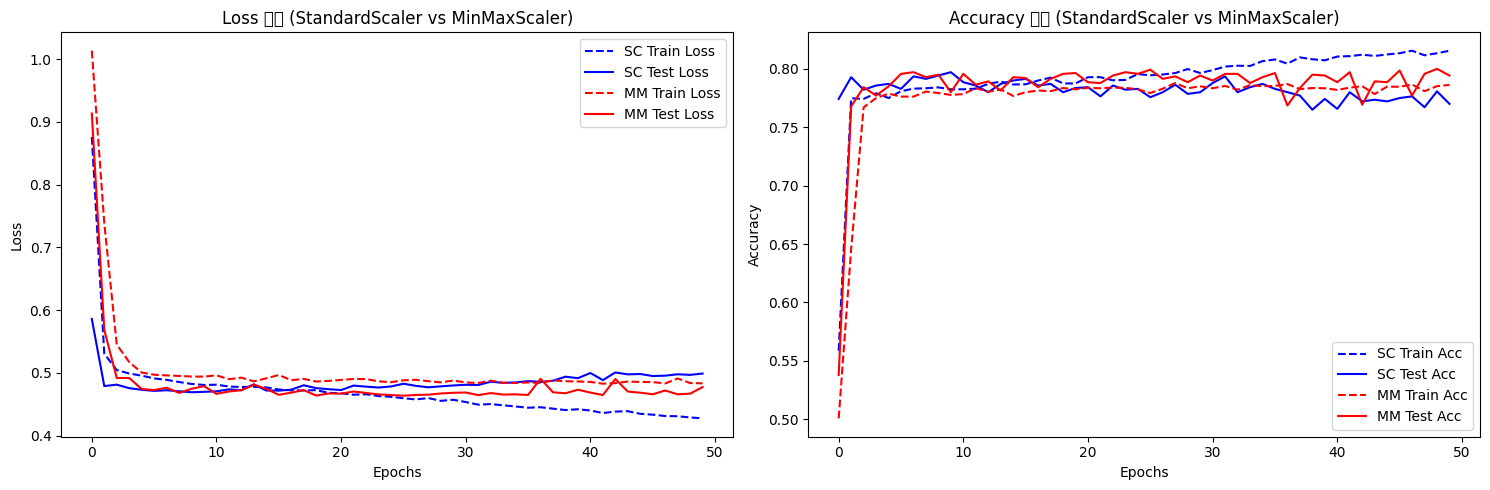

[StandardScaler] Train Acc: 0.8155 | Test Acc: 0.7700
[MinMaxScaler]   Train Acc: 0.7863 | Test Acc: 0.7943


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss 비교
axes[0].plot(history_sc['train_loss'], label='SC Train Loss', color='blue', linestyle='--')
axes[0].plot(history_sc['test_loss'],  label='SC Test Loss',  color='blue')
axes[0].plot(history_mm['train_loss'], label='MM Train Loss', color='red',  linestyle='--')
axes[0].plot(history_mm['test_loss'],  label='MM Test Loss',  color='red')
axes[0].set_title('Loss 비교 (StandardScaler vs MinMaxScaler)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy 비교
axes[1].plot(history_sc['train_acc'], label='SC Train Acc', color='blue', linestyle='--')
axes[1].plot(history_sc['test_acc'],  label='SC Test Acc',  color='blue')
axes[1].plot(history_mm['train_acc'], label='MM Train Acc', color='red',  linestyle='--')
axes[1].plot(history_mm['test_acc'],  label='MM Test Acc',  color='red')
axes[1].set_title('Accuracy 비교 (StandardScaler vs MinMaxScaler)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"[StandardScaler] Train Acc: {history_sc['train_acc'][-1]:.4f} | Test Acc: {history_sc['test_acc'][-1]:.4f}")
print(f"[MinMaxScaler]   Train Acc: {history_mm['train_acc'][-1]:.4f} | Test Acc: {history_mm['test_acc'][-1]:.4f}")

## 실험 결과

- Test Accuracy와 Loss는 두 방법 모두 비슷
- StandardScaler는 Train/Test 간 과적합이 발생
- MinMaxScaler는 Train/Test가 안정적으로 수렴
- → **MinMaxScaler 채택**

다음 실험(experiment3)에서는 MinMaxScaler 고정 후 결측치 처리 방법 비교 예정